In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import real_amplitudes as RealAmplitudes, StatePreparation
from qiskit.quantum_info import Statevector

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# src 모듈 임포트
try:
    from src.problem_setup import get_b_statevector, create_b_vector_gaussian
    from src.solvers.exact import run_vqe_for_poisson as run_exact
    from src.solvers.hybrid import run_vqe_hybrid_v2 as run_hybrid
    from src.solvers.hardware import run_vqe_fully_hardware_v2 as run_hardware
    from src.decomposition import dict_to_operator, decompose_A_matrix
    from src.ansatz import create_qaoa_ansatz
    print("✅ 모든 모듈 임포트 성공!")
except ImportError as e:
    print(f"❌ 임포트 실패: {e}")
    print("폴더 구조가 올바른지 확인해주세요 (src/solvers/ 등).")

✅ 모든 모듈 임포트 성공!


Target System: 3 Qubits, 2 Layers, Optimizer: COBYLA
Target Vector b created. Shape: (8,)
Ansatz Parameters: 4


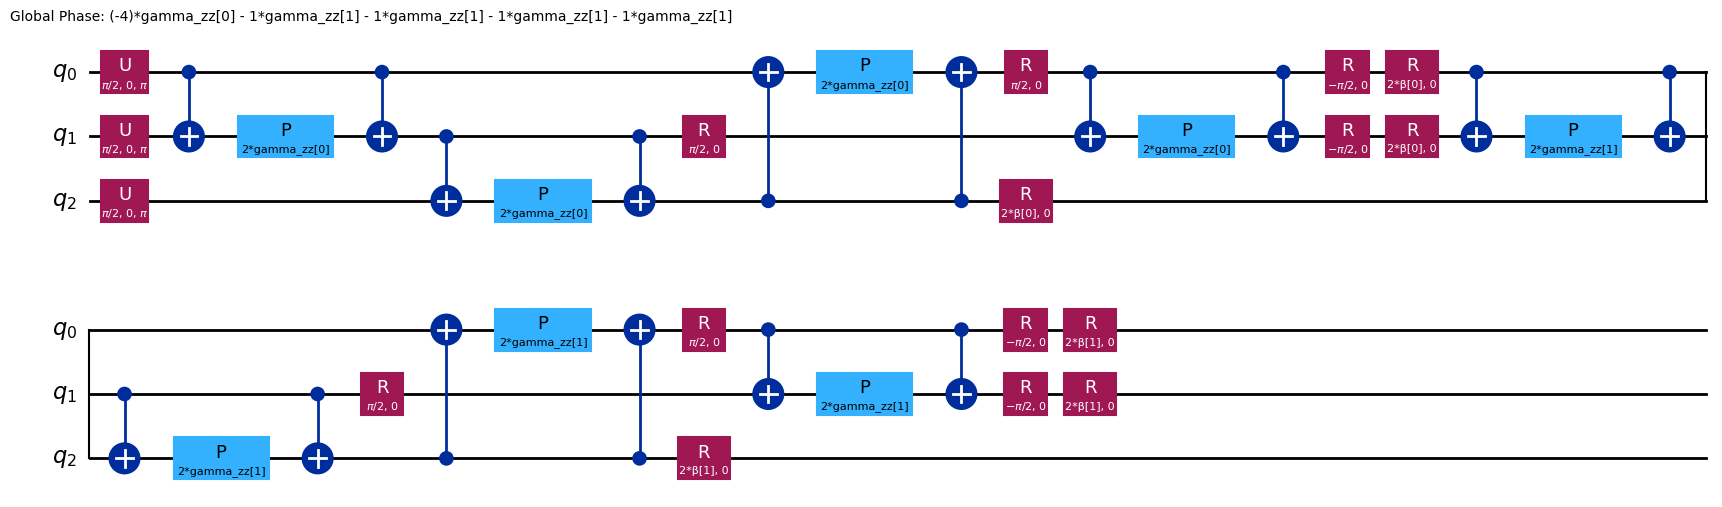

In [15]:
# --- 실험 파라미터 ---
m_qubits = 3  # 3큐비트
layers = 2    # Ansatz 깊이
optimizer = 'COBYLA' # 후보 : 'COBYLA', 'Nelder-Mead', 'Powell', 'SLSQP', 'SPSA'
options = {'maxiter': 3000, 'tol': 1e-4}

print(f"Target System: {m_qubits} Qubits, {layers} Layers, Optimizer: {optimizer}")

# 1. 문제 정의 (Gaussian Source b)
b_vec, b_data = get_b_statevector(m_qubits, create_b_vector_gaussian)
print(f"Target Vector b created. Shape: {b_data.shape}")

# 2. Ansatz 생성 (QAOA 대신 RealAmplitudes 사용)
#ansatz = RealAmplitudes(m_qubits, entanglement='linear', reps=layers)
ansatz = create_qaoa_ansatz(m_qubits, layers=layers)
print(f"Ansatz Parameters: {ansatz.num_parameters}")
ansatz.decompose().draw('mpl') # 회로를 보고 싶다면 주석 해제

In [16]:
print("Running Exact Solver (Statevector)...")
res_exact, _ = run_exact(
    m_qubits, 
    ansatz, 
    b_creation_func=create_b_vector_gaussian,
    optimizer=optimizer,
    options=options
)

print(f"Exact Solver Cost: {res_exact.fun:.6f}")

Running Exact Solver (Statevector)...
VQE 최적화 시작 (파라미터 수: 4)...
Iteration  814: Cost = 0.05222836
최적화 완료.
Exact Solver Cost: 0.052228


In [17]:
print("Running Hybrid Solver (EstimatorV2)...")
res_hybrid = run_hybrid(
    m_qubits, 
    ansatz, 
    b_vec, 
    backend_mode='noiseless', # 시뮬레이터 모드 : noisy_sim / noiseless / real
    optimizer=optimizer,
    options=options
)

print(f"Hybrid Solver Cost: {res_hybrid.fun:.6f}")

Running Hybrid Solver (EstimatorV2)...
[INFO] Running on backend: aer_simulator (Mode: noiseless)

[INFO] Starting Optimization with COBYLA...
Hybrid Solver Cost: 0.0522302>=0.0590, Overlap=0.0068)


In [18]:
print("Running Hardware Solver (SamplerV2)...")

# Hardware Solver는 QuantumCircuit 형태의 b가 필요함
b_circuit = QuantumCircuit(m_qubits)
b_circuit.append(StatePreparation(b_data), range(m_qubits))

res_hardware = run_hardware(
    m_qubits, 
    ansatz, 
    b_circuit, 
    backend_mode='noiseless', # 노이즈 없이 로직 검증
    optimizer=optimizer,
    options=options
)

print(f"Hardware Solver Cost: {res_hardware.fun:.6f}")

Running Hardware Solver (SamplerV2)...
[INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...

[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Hardware Solver Cost: 0.0592370.1035, Overlap=0.0037)


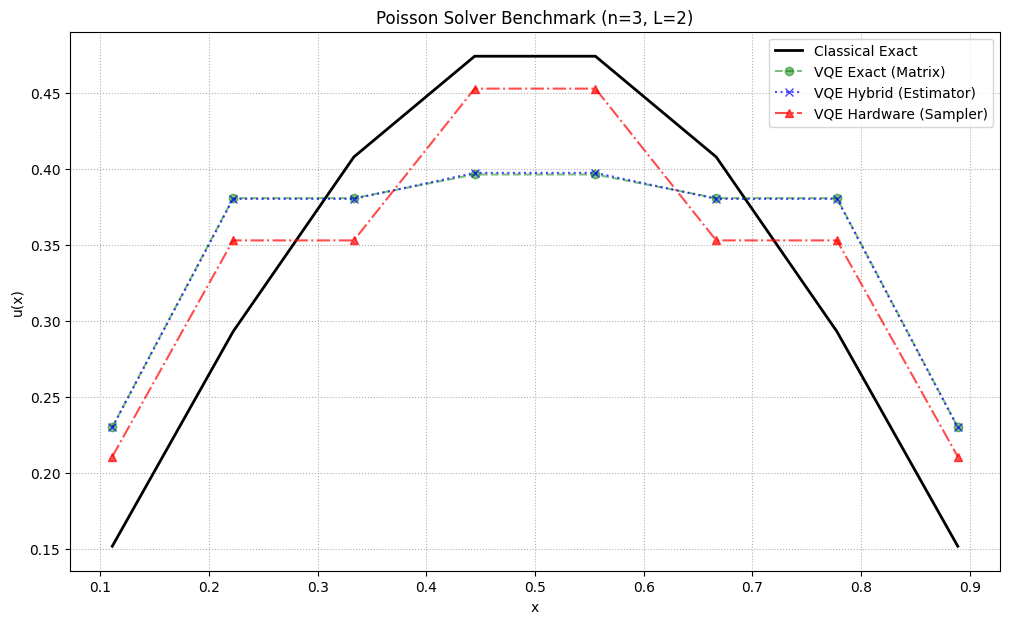

Fidelity Comparison:
  Exact Solver:   0.959080
  Hybrid Solver:  0.959608
  Hardware Solver:0.976187


In [19]:
# --- 유틸리티 함수 정의 ---
import scipy.linalg as la

def get_classical_sol(m):
    # 고전적 해 계산
    n = 2**m
    A_op = dict_to_operator(decompose_A_matrix(m), m)
    grid = np.linspace(0, 1, n+2)[1:-1]
    # Gaussian b 재생성
    sigma, delta = 0.2, 0.5
    b_val = np.exp(-(grid - delta)**2 / (2 * sigma**2))
    
    # Ax = b
    try:
        x = la.solve(A_op.data, b_val)
    except:
        x = la.pinv(A_op.data) @ b_val
    return x / np.linalg.norm(x)

def align_phase(target, ref):
    # 위상 정렬
    overlap = np.dot(ref.conj(), target)
    if abs(overlap) < 1e-10: return target
    return target / (overlap / abs(overlap))

# --- 결과 취합 ---
exact_sol = get_classical_sol(m_qubits)

# 각 솔버의 최적 파라미터로 상태 벡터 생성
state_exact = Statevector(ansatz.assign_parameters(res_exact.x)).data
state_hybrid = Statevector(ansatz.assign_parameters(res_hybrid.x)).data
state_hw = Statevector(ansatz.assign_parameters(res_hardware.x)).data

# 위상 정렬 적용
aligned_exact = align_phase(state_exact, exact_sol)
aligned_hybrid = align_phase(state_hybrid, exact_sol)
aligned_hw = align_phase(state_hw, exact_sol)

# --- 그래프 그리기 ---
x_grid = np.linspace(0, 1, 2**m_qubits + 2)[1:-1]

plt.figure(figsize=(12, 7))
plt.plot(x_grid, exact_sol.real, 'k-', linewidth=2, label='Classical Exact')
plt.plot(x_grid, aligned_exact.real, 'go--', alpha=0.5, label='VQE Exact (Matrix)')
plt.plot(x_grid, aligned_hybrid.real, 'bx:', alpha=0.7, label='VQE Hybrid (Estimator)')
plt.plot(x_grid, aligned_hw.real, 'r^-.', alpha=0.7, label='VQE Hardware (Sampler)')

plt.title(f"Poisson Solver Benchmark (n={m_qubits}, L={layers})")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Fidelity 출력
f_ex = abs(np.dot(exact_sol.conj(), state_exact))**2
f_hy = abs(np.dot(exact_sol.conj(), state_hybrid))**2
f_hw = abs(np.dot(exact_sol.conj(), state_hw))**2

print(f"Fidelity Comparison:")
print(f"  Exact Solver:   {f_ex:.6f}")
print(f"  Hybrid Solver:  {f_hy:.6f}")
print(f"  Hardware Solver:{f_hw:.6f}")

In [ ]:
try:
    print("Running Hardware Solver on Real Device...")
    res_real = run_hardware(
        m_qubits, 
        ansatz, 
        b_circuit, 
        backend_mode='real',
        optimizer='COBYLA',
        options={'maxiter': 50} # 테스트니까 조금만
    )
    print("Real Hardware Success!")
except Exception as e:
    print(f"Hardware execution failed: {e}")

# 계산비용이 굉장히 큼 1 iteration에 약 1.5분 소요 

Running Hardware Solver on Real Device...
[INFO] Setting up backend for mode: real


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-12-22 12:20:38,264: Default instance not set. Searching all available instances.


[INFO] Searching for the least busy real backend...
[INFO] Connected to real backend: ibm_torino
[INFO] Using V2 Primitives on backend: ibm_torino
[INFO] Generating and transpiling Hadamard test circuits...

[INFO] Starting VQE Optimization (COBYLA, Backend: real)...


/opt/anaconda3/envs/qiskit-vqe/lib/python3.13/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 11
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


Hardware execution failed: 'Unable to retrieve result for job d54ble0nsj9s73b1mokg. Job was cancelled.'
